# Dev for ophys-mFISH GLM
- Using DataAsset from design matrix capsule
- Test using one session (session_name = 'multiplane-ophys_721291_2024-05-16_08-57-00')
- L2 regularized Gaussian GLM

In [1]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json
from matplotlib import pyplot as plt
from dask import delayed, compute
from distributed import Client

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline
import capsule_utils


In [2]:
# data info
session_name = 'multiplane-ophys_721291_2024-05-16_08-57-00'
data_type = 'filtered_events'
dm_version = 0

# for now dataAssets are manually attached
# in the future, it should include searching and attaching corresponding data assets


# load data
data_path = Path('/root/capsule/data')

dm_path = data_path / f'design_matrix_v{dm_version:02}_{session_name}'
rm_path = data_path / f'response_matrix_{session_name}_{data_type}'

x_fn = dm_path / 'design_matrix.nc'

X = xr.open_dataarray(x_fn, mmap=False)

run_params_fn = dm_path / 'run_params.json'
with open(run_params_fn, 'r') as f:
    run_params = json.load(f)

unstd_features_fn = dm_path / 'unstd_features.npy'
unstd_features = np.load(unstd_features_fn, allow_pickle=True).item()


response_fn = rm_path / 'response_matrix.nc'

response = xr.open_dataarray(response_fn, mmap=False)

assert X.shape[0] == response.shape[0]

response_info_fn = rm_path / 'response_info.npy'
response_info = np.load(response_info_fn, allow_pickle=True).item()
ophys_frame_rate = response_info['ophys_frame_rate']

In [3]:
# Trim frames based on kernel offsets
offsets = [int(w.split('_')[1]) for w in X.weights.values]
min_offset = min(min(offsets), 0)
max_offset = max(max(offsets), 0)
use_indices = range(max_offset, X.shape[0] + min_offset)  # min_offset is negative or 0

X_trim = X[use_indices, :]
response_trim = response[use_indices, :]


In [4]:
# defining fit params
fit_params = {
    'ElasticNet': False,                        # Use ElasticNet (True) or Ridge (False) regression
    'ElasticNet_alpha':0.95,                    #
    'L2_grid_range':[.1, 10000],                # Min/Max L2 values
    'L2_grid_num': 40,                          # Number of L2 values
    'L2_grid_type':'log',                       # how to space L2 options, must be: 'log' or 'linear'
    'cv_fold': 5,                               # Number of cross-validation folds
    'cv_nested_fold': 5,                        # Number of nested cross-validation folds, for hyperparameter optimization (e.g., L2 lambda)
    'cv_stratify': {                            # Stratify cross-validation folds by these variables (['time', 'image_name', 'running_speed', 'lick_frequency', 'engagement', 'rolling_performance'])
        'variables': ['time', 'running_speed', 'lick', 'rolling_performance'], # 'time', 'running_speed', 'lick', 'rolling_performance' 
        'num_time_stratification': 5,           # Number of stratification for time. The rest are binary (at least for now)
        # 'stratification_threshold': 0.2,        # Threshold for stratification variable. If smaller portion is lower than this threshold, stratification is not performed (too rare incidents)
        'running_smoothing_s': 10,              # Smoothing window for running speed (seconds)
        'running_threshold': 5,                 # Threshold for running variable (cm/s)
        'rolling_performance_threshold': 1.5,   # Threshold for rolling performance variable (x rewards / minute). Previously 'engagement', but to generalize across learning phases
        'lick_threshold': 20,                   # Threshold for lick variable (licks / min)
        }
}



# Stratification
- Requires unstandardized data for running and pupil
- Should I load BOD or attach that from design matrix?
- Let's attach them from design matrix, since I want to make this capsule be independent from COMB.

In [5]:
# For multiple stratification, stratify per variable and then make combinations

def get_var_traces_from_X(X, use_indices, keyword):
    var_inds = np.where([keyword in w for w in X.weights.values])[0]
    if len(var_inds) > 0:
        #TODO: consider when running is not in the weights. Need to load BOD and interpolate running to X_trim timepoints
        if len(np.where([f'{keyword}_0' in w for w in X.weights.values])[0]) > 0:
            var_traces = X.sel(weights=f'{keyword}_0')[use_indices]
        else:
            first_delay_trace = X.isel(weights=var_inds[0])
            first_delay = int(str(first_delay_trace.weights.values).split('_')[-1])
            var_traces = first_delay_trace.shift(timestamps=-first_delay)[use_indices]            
    else:  #TODO: implement getting the feature trace from... bod?
        var_traces = None        
    return var_traces


def set_stratified_list(fit_params, X_trim, unstd_features, use_indices, ophys_frame_rate):
    num_stratify_vars = len(fit_params['cv_stratify']['variables'])
    stratified_list = []
    for var in fit_params['cv_stratify']['variables']:    
        if var == 'time':  # divide all frames into cv_fold
            stratify_borders = np.floor(np.linspace(0, X_trim.shape[0], fit_params['cv_stratify']['num_time_stratification'] + 1)).astype(int)        
            stratified = []
            for i in range(fit_params['cv_stratify']['num_time_stratification']):
                stratified.append(np.arange(stratify_borders[i], stratify_borders[i+1]))
            stratified_list.append(stratified)
        elif var == 'running_speed': #TODO: save raw running and pupil data in a separate file for design_matrix. Or use BOD (needs data search and attachment)
            keyword = 'running'
            running_speed = unstd_features['running'][use_indices]
            assert len(running_speed) == X_trim.shape[0]
            # smooth running_speed
            running_speed = xr.DataArray(running_speed, dims='timestamps')
            running_speed['timestamps'] = X_trim['timestamps']
            smoothing_window = np.round(ophys_frame_rate * fit_params['cv_stratify']['running_smoothing_s']).astype(int)
            sm_running_speed = running_speed.rolling(timestamps=smoothing_window, center=True).mean().ffill(dim='timestamps').bfill(dim='timestamps')

            # binarization
            running_frames = np.where(sm_running_speed > fit_params['cv_stratify']['running_threshold'])[0]
            stationary_frames = np.setdiff1d(np.arange(X_trim.shape[0]), running_frames)
            stratified = [running_frames, stationary_frames]
            stratified_list.append(stratified)
        elif var == 'rolling_performance':
            keyword = 'hits'
            correct = get_var_traces_from_X(X, use_indices, keyword)
            # rolling sum
            num_frames_one_min = np.round(ophys_frame_rate * 60).astype(int)
            rolling_performance = correct.rolling(timestamps=num_frames_one_min, center=True).sum().ffill(dim='timestamps').bfill(dim='timestamps')
            # binarization
            performing_frames = np.where(rolling_performance > fit_params['cv_stratify']['rolling_performance_threshold'])[0]
            nonperforming_frames = np.setdiff1d(np.arange(X_trim.shape[0]), performing_frames)
            stratified = [performing_frames, nonperforming_frames]
            stratified_list.append(stratified)
        elif var == 'lick':
            licks_trace = unstd_features['licks'][use_indices]
            assert len(licks_trace) == X_trim.shape[0]
            licks = xr.DataArray(licks_trace, dims='timestamps')
            # add timestamps to licks
            licks['timestamps'] = X_trim['timestamps']
            # rolling sum
            num_frames_one_min = np.round(ophys_frame_rate * 60).astype(int)
            lick_freq = licks.rolling(timestamps=num_frames_one_min, center=True).sum().ffill(dim='timestamps').bfill(dim='timestamps')
            # binarization
            licking_frames = np.where(lick_freq > fit_params['cv_stratify']['lick_threshold'])[0]
            nonlicking_frames = np.setdiff1d(np.arange(X_trim.shape[0]), licking_frames)
            stratified = [licking_frames, nonlicking_frames]
            stratified_list.append(stratified)
        else:
            print(f'{var} not implemented for stratification. Continue...')
    return stratified_list
    

# Make nested cross-validation sets
- Calculate lambda per fold (within each training set, i.e., inner training set)
    - Use mean lambda across inner folds
- Build the model using the lambda value within the outer training set
- Calculate model performance from the outer test set
- "Average model" by averaging all the coefficients - just for the record
    - To have a single model per session (just in case)
    - Compare fitting with each fold models

In [6]:
def get_stratified_folds(fit_params, stratified_list):
    num_stratify_vars = len(fit_params['cv_stratify']['variables'])
    cv_fold = fit_params['cv_fold']
    cv_nested_fold = fit_params['cv_nested_fold'] 

    # collect unique sets across all stratification variables
    unique_sets = []
    for i in range(num_stratify_vars):
        if i == 0:
            unique_sets = stratified_list[i]
        else:
            unique_sets = [np.intersect1d(a, b) for a in unique_sets for b in stratified_list[i]]
    assert len(unique_sets) == np.multiply.reduce([len(s) for s in stratified_list])

    # Randomly divide each set into cv_fold * cv_nested_fold
    total_folds = cv_fold * cv_nested_fold
    stratify_folds_each_set = []
    for us in unique_sets:
        np.random.shuffle(us)
        stratify_folds_each_set.append(np.array_split(us, total_folds))

    # Combine each folds in each set to generate stratified folds
    stratified_frames = [np.concatenate([s[i] for s in stratify_folds_each_set]) for i in range(total_folds)]
    assert len(stratified_frames) == total_folds

    # shuffle and split stratified folds into cv_fold
    # To randomly distribute total number of frames
    stratified_frames = [stratified_frames[i] for i in np.random.permutation(np.arange(total_folds))]
    cv_inds_stratified = np.array_split(np.arange(total_folds), cv_fold)
    assert np.all([len(cv_inds_stratified[i]) == cv_nested_fold for i in range(cv_fold)])    
    
    return stratified_frames, cv_inds_stratified
   

In [7]:
stratified_list = set_stratified_list(fit_params, X_trim, unstd_features, use_indices, ophys_frame_rate)
stratified_frames, cv_inds_stratified = get_stratified_folds(fit_params, stratified_list)

# Run L2 regularization and fitting
- Log lambda and coefficients for each fold
    - Include drop-out models in each fold ('full-model' is included)
    - Log lambda and coefficients for each model in each fold
    - Encoding scores (with adjustment)
- Full models
    - "Fold prediction" as the predicted traces in each cross-validation
    - "Average model" as averaging coefficients across cv
    - Log variance explained in each method of full model
        - Log them in both training and test sets, to calculate overfitting

In [8]:
def masked_variance_ratio(fit_trace_arr, W, X, mask): 
    '''
    Computes the fraction of variance in fit_trace_arr explained by the linear model Y = X*W
    but only looks at the timepoints in mask
    

    fit_trace_arr: (n_timepoints, n_cells)
    W: Xarray (n_kernel_params, n_cells)
    X: Xarray (n_timepoints, n_kernel_params)
    mask: bool vector (n_timepoints,)
    '''

    Y = X.values @ W.values

    # Define variance function that lets us isolate the mask timepoints
    def my_var(trace, support_mask):
        if len(np.shape(trace)) ==1:
            trace = trace.values[:,np.newaxis]
        mu = np.mean(trace,axis=0)
        return np.mean((trace[support_mask,:]-mu)**2,axis=0)

    var_total = my_var(fit_trace_arr, mask)#Total variance in the ophys trace for each cell
    var_resid = my_var(fit_trace_arr-Y, mask)#Residual variance in the difference between the model and data
    return (var_total - var_resid) / var_total  # Fraction of variance explained by linear model


def evaluate_ridge(fit, design,run_params,session):
    '''
        Finds the best L2 value by fitting the model on a grid of L2 values and reporting training/test error
    
        fit, model dictionary
        design, design matrix
        run_params, dictionary of parameters, which needs to include:
            L2_optimize_by_cell     # If True, uses the best L2 value for each cell
            L2_optimize_by_session  # If True, uses the best L2 value for this session
            L2_use_fixed_value      # If True, uses the hard coded L2_fixed_lambda
            L2_fixed_lambda         # This value is used if L2_use_fixed_value
            L2_grid_range           # Min/Max L2 values for optimization
            L2_grid_num             # Number of L2 values for optimization

        returns fit, with the values added:
            L2_grid                 # the L2 grid evaluated (if L2_optimize_by_cell, or L2_optimize_by_session)
            avg_L2_regularization      # the average optimal L2 value, or the fixed value
            cell_L2_regularization     # the optimal L2 value for each cell (if L2_optimize_by_cell)
    '''
    if run_params['L2_use_fixed_value']:
        print('Using a hard-coded regularization value')
        fit['avg_L2_regularization'] = run_params['L2_fixed_lambda']
    elif run_params['L2_optimize_by_cre']:
        print('Using a hard-coded regularization value for each cre line')
        this_cre = session.metadata['cre_line']
        fit['avg_L2_regularization'] = run_params['L2_cre_values'][this_cre]
    elif not fit['ok_to_fit_preferred_engagement']:
        print('\tSkipping ridge evaluation because insufficient preferred engagement timepoints')
        fit['avg_L2_regularization'] = np.nan      
        fit['cell_L2_regularization'] = np.empty((fit['fit_trace_arr'].shape[1],))
        fit['L2_test_cv'] = np.empty((fit['fit_trace_arr'].shape[1],)) 
        fit['L2_train_cv'] = np.empty((fit['fit_trace_arr'].shape[1],)) 
        fit['L2_at_grid_min'] = np.empty((fit['fit_trace_arr'].shape[1],))
        fit['L2_at_grid_max'] = np.empty((fit['fit_trace_arr'].shape[1],))
        fit['cell_L2_regularization'][:] = np.nan
        fit['L2_test_cv'][:] = np.nan
        fit['L2_train_cv'][:] =np.nan
        fit['L2_at_grid_min'][:] =np.nan
        fit['L2_at_grid_max'][:] =np.nan
    elif run_params['ElasticNet']:
        print('Evaluating a grid of regularization values for Lasso')
        fit = evaluate_lasso(fit, design, run_params)
    else:
        print('Evaluating a grid of regularization values')
        if run_params['L2_grid_type'] == 'log':
            fit['L2_grid'] = np.geomspace(run_params['L2_grid_range'][0], run_params['L2_grid_range'][1],num = run_params['L2_grid_num'])
        else:
            fit['L2_grid'] = np.linspace(run_params['L2_grid_range'][0], run_params['L2_grid_range'][1],num = run_params['L2_grid_num'])
        train_cv = np.empty((fit['fit_trace_arr'].shape[1], len(fit['L2_grid']))) 
        test_cv  = np.empty((fit['fit_trace_arr'].shape[1], len(fit['L2_grid']))) 
        X = design.get_X()
      
        # Iterate over L2 Values 
        for L2_index, L2_value in enumerate(fit['L2_grid']):
            cv_var_train = np.empty((fit['fit_trace_arr'].shape[1], len(fit['ridge_splits'])))
            cv_var_test = np.empty((fit['fit_trace_arr'].shape[1], len(fit['ridge_splits'])))

            # Iterate over CV splits
            for split_index, test_split in tqdm(enumerate(fit['ridge_splits']), total=len(fit['ridge_splits']), desc='    Fitting L2, {}'.format(L2_value)):
                train_split = np.sort(np.concatenate([split for i, split in enumerate(fit['ridge_splits']) if i!=split_index]))
                X_test  = X[test_split,:]
                X_train = X[train_split,:]
                fit_trace_train = fit['fit_trace_arr'][train_split,:]
                fit_trace_test  = fit['fit_trace_arr'][test_split,:]
                W = fit_regularized(fit_trace_train, X_train, L2_value)
                cv_var_train[:,split_index] = variance_ratio(fit_trace_train, W, X_train)
                cv_var_test[:,split_index]  = variance_ratio(fit_trace_test, W, X_test)

            train_cv[:,L2_index] = np.mean(cv_var_train,1)
            test_cv[:,L2_index]  = np.mean(cv_var_test,1)

        fit['avg_L2_regularization'] = np.mean([fit['L2_grid'][x] for x in np.argmax(test_cv,1)])      
        fit['cell_L2_regularization'] = [fit['L2_grid'][x] for x in np.argmax(test_cv,1)]     
        fit['L2_test_cv'] = test_cv
        fit['L2_train_cv'] = train_cv
        fit['L2_at_grid_min'] = [x==0 for x in np.argmax(test_cv,1)]
        fit['L2_at_grid_max'] = [x==(len(fit['L2_grid'])-1) for x in np.argmax(test_cv,1)]
    return fit

## For one set of CV

In [9]:
def collect_var_ratio_across_lambdas_and_nested_folds(X, y, nested_fold_inds, fit_params):
    assert fit_params['cv_nested_fold'] == len(nested_fold_inds)
    
    test_lams = np.geomspace(fit_params['L2_grid_range'][0], fit_params['L2_grid_range'][1], fit_params['L2_grid_num'])

    var_ratio_xr_collected = None  # Start with no data
    W_all_collected = None
    for nfi in range(fit_params['cv_nested_fold']):
        nested_train_inds = np.concatenate([nested_fold_inds[i] for i in range(len(nested_fold_inds)) if i != nfi])
        nested_test_inds = nested_fold_inds[nfi]
        X_train = X[nested_train_inds, :]
        X_test = X[nested_test_inds, :]
        y_train = y[nested_train_inds, :]
        y_test = y[nested_test_inds, :]
        assert X_train.shape[0] + X_test.shape[0] == X.shape[0]

        var_ratio_xr, W_all = get_var_ratio_xr_across_lambdas(X_train, X_test, y_train, y_test, test_lams)
        var_ratio_xr = var_ratio_xr.expand_dims(nested_fold_ind=[nfi])
        W_all = W_all.expand_dims(nested_fold_ind=[nfi])

        if var_ratio_xr_collected is None:
            var_ratio_xr_collected = var_ratio_xr
        else:
            var_ratio_xr_collected = xr.concat([var_ratio_xr_collected, var_ratio_xr], dim="nested_fold_ind")
        
        if W_all_collected is None:
            W_all_collected = W_all
        else:
            W_all_collected = xr.concat([W_all_collected, W_all], dim="nested_fold_ind")
    return var_ratio_xr_collected, W_all_collected


def get_var_ratio_xr_across_lambdas(X_train, X_test, y_train, y_test, test_lams):
    var_ratio_xr = None  # Start with no data
    W_all = None

    for lam in test_lams:
        # Fit the regularized model
        W = fit_regularized(y_train, X_train, lam)
        
        # Compute the variance ratio
        var_ratio = variance_ratio(y_test, W, X_test)

        # Expand along the 'lam' dimension
        var_ratio = var_ratio.expand_dims(lam=[lam])
        
        # Concatenate with the existing var_ratio_xr
        if var_ratio_xr is None:
            var_ratio_xr = var_ratio  # Initialize with the first DataArray
        else:
            var_ratio_xr = xr.concat([var_ratio_xr, var_ratio], dim="lam")
        
        # Concatenate with the existing W_all
        if W_all is None:
            W_all = W
        else:
            W_all = xr.concat([W_all, W], dim="lam")
        
    return var_ratio_xr, W_all

In [10]:
def fit(y, X):
    '''
    Analytical OLS solution to linear regression. 

    y: shape (n_timestamps * n_cells)
    X: shape (n_timestamps * n_kernel_params)
    '''
    W = np.dot(np.linalg.inv(np.dot(X.T.values, X.values)), np.dot(X.T.values, y.values))
    return W


def fit_regularized(y, X, lam):
    '''
    Analytical OLS solution with added L2 regularization penalty. 

    y: xr DataArray shape (n_timestamps * n_cells)
    X: xr DataArray shape (n_timestamps * n_kernel_params)
    lam (float): Strength of L2 regularization per cell (hyperparameter to tune)

    Returns: XArray
    '''
    assert len(y.shape) == 2 # 2 dimensional, even if there is only one cell
    
    # Compute the weights
    if lam == 0:
        W = fit(y, X)
    else:
        W = np.dot(np.linalg.inv(np.dot(X.T.values, X.values) + lam * np.eye(X.shape[-1])),
               np.dot(X.T.values, y.values))
    # if len(W.shape) == 1: # in case of single neuron
    #     W = W[:, None]

    # Make xarray
    cellids = y['cell_roi_id'].values
    W_xarray= xr.DataArray(
            W, 
            dims =('weights','cell_roi_id'), 
            coords = {  'weights':X.weights.values, 
                        'cell_roi_id':cellids}
            )
    return W_xarray


def variance_ratio(y, W, X): 
    '''
    Computes the fraction of variance in fit_trace_arr explained by the linear model Y = X*W
    
    fit_trace_arr: (n_timepoints, n_cells)
    W: Xarray (n_kernel_params, n_cells)
    X: Xarray (n_timepoints, n_kernel_params)
    '''
    y_hat = X.values @ W.values
    var_total = np.var(y, axis=0)   # Total variance in the ophys trace for each cell
    var_resid = np.var(y - y_hat, axis=0) # Residual variance in the difference between the model and data
    return (var_total - var_resid) / var_total  # Fraction of variance explained by linear model


In [11]:
# get test and train fold inds for one cross-validation set
test_fold_ind = 0  # range(fit_params['cv_fold])
train_fold_inds = np.setdiff1d(np.arange(fit_params['cv_fold']), test_fold_ind)

test_stratified_fold_inds = cv_inds_stratified[test_fold_ind]
train_stratified_fold_inds = np.concatenate([cv_inds_stratified[i] for i in train_fold_inds])

test_frames = np.concatenate([stratified_frames[i] for i in test_stratified_fold_inds])
train_frames = np.concatenate([stratified_frames[i] for i in train_stratified_fold_inds])

X_train_outer = X_trim[train_frames, :]
X_test_outer = X_trim[test_frames, :]
y_train_outer = response_trim[train_frames, :]
y_test_outer = response_trim[test_frames, :]

# get cross validation folds for hyperparameter optimization within the training set
nested_stratified_fold_inds_arr = np.array([cv_inds_stratified[i] for i in train_fold_inds])
nested_stratified_fold_inds = [nested_stratified_fold_inds_arr[:, i] for i in range(fit_params['cv_nested_fold'])]
nested_fold_frames = [np.sort(np.concatenate([stratified_frames[i] for i in nested_stratified_fold_inds[j]])) for j in range(fit_params['cv_nested_fold'])]
nested_fold_inds = [np.where(np.isin(train_frames, nff))[0] for nff in nested_fold_frames]

# assert no overlap between nested folds
for i in range(len(nested_fold_inds)):
    for j in range(len(nested_fold_inds)):
        if i != j:
            assert len(np.intersect1d(nested_fold_inds[i], nested_fold_inds[j])) == 0
# assert all train frames are included in nested folds
assert (np.sort(np.concatenate([nested_fold_frames[i] for i in range(len(nested_fold_frames))])) == np.sort(train_frames)).all()
assert (np.sort(np.concatenate([nested_fold_inds[i] for i in range(len(nested_fold_inds))])) == np.arange(len(train_frames))).all()


In [16]:
def collect_fold_results(run_params, fit_params, X_train_outer, X_test_outer, y_train_outer, y_test_outer, nested_fold_inds,
                         use_dask=True, num_cores=None):
    models = run_params['dropouts'].keys()
    if use_dask:
        lambdas_fold, W_fold, var_ratio_train_fold, var_ratio_test_fold, vr_test_train_ratio_fold = \
            collect_fold_results_dask(run_params, fit_params, X_train_outer, X_test_outer, y_train_outer, y_test_outer, nested_fold_inds)
    else:
        for mi, model_label in enumerate(models):
            model_results = collect_model_results(run_params, fit_params, X_train_outer, X_test_outer, y_train_outer, y_test_outer, nested_fold_inds, model_label)
            (lambdas, W_model, var_ratio_train, var_ratio_test, vr_test_train_ratio) = model_results
            
            # Collect results
            if mi == 0:
                lambdas_fold = lambdas
                W_fold = W_model
                var_ratio_train_fold = var_ratio_train
                var_ratio_test_fold = var_ratio_test
                vr_test_train_ratio_fold = vr_test_train_ratio
            else:
                lambdas_fold = xr.concat([lambdas_fold, lambdas], dim='model')
                W_fold = xr.concat([W_fold, W_model], dim='model')
                var_ratio_train_fold = xr.concat([var_ratio_train_fold, var_ratio_train], dim='model')
                var_ratio_test_fold = xr.concat([var_ratio_test_fold, var_ratio_test], dim='model')
            vr_test_train_ratio_fold = xr.concat([vr_test_train_ratio_fold, vr_test_train_ratio], dim='model')
            
    return lambdas_fold, W_fold, var_ratio_train_fold, var_ratio_test_fold, vr_test_train_ratio_fold


def collect_fold_results_dask(run_params, fit_params, X_train_outer, X_test_outer, y_train_outer, y_test_outer, nested_fold_inds, num_cores=None):
    with Client() as client:
        tasks = []
        models = run_params['dropouts'].keys()
        for mi, model_label in enumerate(models):
            task = delayed(collect_model_results)(run_params, fit_params, X_train_outer, X_test_outer, y_train_outer, y_test_outer, nested_fold_inds, model_label)
            tasks.append(task)
        if num_cores is None:
            model_results = compute(*tasks)
        else:
            model_results = compute(*tasks, num_workers=num_cores)
        
    # Collect results
    for mi in range(len(models)):
        (lambdas, W_model, var_ratio_train, var_ratio_test, vr_test_train_ratio) = model_results[mi]
        if mi == 0:
            lambdas_fold = lambdas
            W_fold = W_model
            var_ratio_train_fold = var_ratio_train
            var_ratio_test_fold = var_ratio_test
            vr_test_train_ratio_fold = vr_test_train_ratio
        else:
            lambdas_fold = xr.concat([lambdas_fold, lambdas], dim='model')
            W_fold = xr.concat([W_fold, W_model], dim='model')
            var_ratio_train_fold = xr.concat([var_ratio_train_fold, var_ratio_train], dim='model')
            var_ratio_test_fold = xr.concat([var_ratio_test_fold, var_ratio_test], dim='model')
            vr_test_train_ratio_fold = xr.concat([vr_test_train_ratio_fold, vr_test_train_ratio], dim='model')
            
    return lambdas_fold, W_fold, var_ratio_train_fold, var_ratio_test_fold, vr_test_train_ratio_fold


def collect_model_results(run_params, fit_params, X_train_outer, X_test_outer, y_train_outer, y_test_outer, nested_fold_inds, model_label):
    test_lams = np.geomspace(fit_params['L2_grid_range'][0], fit_params['L2_grid_range'][1], fit_params['L2_grid_num'])
    test_lams = xr.DataArray(test_lams, dims={'lam'})
    kernels = run_params['dropouts'][model_label]['kernels']
    weights = [w for w in X_train_outer.weights.values if np.any([(k in w) for k in kernels])]
    X_train_outer_model = X_train_outer.sel(weights=weights)
    x_test_outer_model = X_test_outer.sel(weights=weights)
    var_ratio_xr_collected, W_all_collected = collect_var_ratio_across_lambdas_and_nested_folds(X_train_outer_model, y_train_outer, nested_fold_inds, fit_params)
    
    best_lam_inds = var_ratio_xr_collected.mean(dim="nested_fold_ind").argmax(dim="lam")
    lambdas = test_lams[best_lam_inds]
    
    # Train using the lambda
    assert len(lambdas) == len(y_train_outer.cell_roi_id)
    num_cell = len(lambdas)
    W_model = None
    for ci in range(num_cell):
        W_cell = fit_regularized(y_train_outer.isel(cell_roi_id=[ci]), X_train_outer_model, lambdas[ci].values)
        if W_model is None:
            W_model = W_cell
        else:
            W_model = xr.concat([W_model, W_cell], dim="cell_roi_id")
            
    # Calculate performance on train and test sets
    var_ratio_train = variance_ratio(y_train_outer, W_model, X_train_outer_model)
    var_ratio_test = variance_ratio(y_test_outer, W_model, x_test_outer_model)
    vr_test_train_ratio = var_ratio_test / var_ratio_train
    
    # Expand model dimension of the DataArrays
    lambdas = lambdas.expand_dims(model=[model_label])
    W_model = W_model.expand_dims(model=[model_label])
    var_ratio_train = var_ratio_train.expand_dims(model=[model_label])
    var_ratio_test = var_ratio_test.expand_dims(model=[model_label])
    vr_test_train_ratio = vr_test_train_ratio.expand_dims(model=[model_label])
    
    return lambdas, W_model, var_ratio_train, var_ratio_test, vr_test_train_ratio

In [17]:
lambdas_fold, W_fold, var_ratio_train_fold, var_ratio_test_fold, vr_test_train_ratio_fold = \
    collect_fold_results(run_params, fit_params, X_train_outer, X_test_outer, y_train_outer, y_test_outer, nested_fold_inds)

In [21]:
def get_train_test_inds(test_fold_ind, fit_params, stratified_frames, cv_inds_stratified):
    train_fold_inds = np.setdiff1d(np.arange(fit_params['cv_fold']), test_fold_ind)

    test_stratified_fold_inds = cv_inds_stratified[test_fold_ind]
    train_stratified_fold_inds = np.concatenate([cv_inds_stratified[i] for i in train_fold_inds])

    test_frames = np.concatenate([stratified_frames[i] for i in test_stratified_fold_inds])
    train_frames = np.concatenate([stratified_frames[i] for i in train_stratified_fold_inds])

    # get cross validation folds for hyperparameter optimization within the training set
    nested_stratified_fold_inds_arr = np.array([cv_inds_stratified[i] for i in train_fold_inds])
    nested_stratified_fold_inds = [nested_stratified_fold_inds_arr[:, i] for i in range(fit_params['cv_nested_fold'])]
    nested_fold_frames = [np.sort(np.concatenate([stratified_frames[i] for i in nested_stratified_fold_inds[j]])) for j in range(fit_params['cv_nested_fold'])]
    nested_fold_inds = [np.where(np.isin(train_frames, nff))[0] for nff in nested_fold_frames]

    # assert no overlap between nested folds
    for i in range(len(nested_fold_inds)):
        for j in range(len(nested_fold_inds)):
            if i != j:
                assert len(np.intersect1d(nested_fold_inds[i], nested_fold_inds[j])) == 0
    # assert all train frames are included in nested folds
    assert (np.sort(np.concatenate([nested_fold_frames[i] for i in range(len(nested_fold_frames))])) == np.sort(train_frames)).all()
    assert (np.sort(np.concatenate([nested_fold_inds[i] for i in range(len(nested_fold_inds))])) == np.arange(len(train_frames))).all()
    
    return train_frames, test_frames, nested_fold_inds

In [22]:
# get test and train fold inds for one cross-validation set
for test_fold_ind in range(fit_params['cv_fold']):
    train_frames, test_frames, nested_fold_inds = get_train_test_inds(test_fold_ind, fit_params, stratified_frames, cv_inds_stratified)
    
    X_train_outer = X_trim[train_frames, :]
    X_test_outer = X_trim[test_frames, :]
    y_train_outer = response_trim[train_frames, :]
    y_test_outer = response_trim[test_frames, :]
    
    lambdas_fold, W_fold, var_ratio_train_fold, var_ratio_test_fold, vr_test_train_ratio_fold = \
        collect_fold_results(run_params, fit_params, X_train_outer, X_test_outer, y_train_outer, y_test_outer, nested_fold_inds)
    
    lambdas_fold = lambdas_fold.expand_dims(test_fold_ind=[test_fold_ind])
    W_fold = W_fold.expand_dims(test_fold_ind=[test_fold_ind])
    var_ratio_train_fold = var_ratio_train_fold.expand_dims(test_fold_ind=[test_fold_ind])
    var_ratio_test_fold = var_ratio_test_fold.expand_dims(test_fold_ind=[test_fold_ind])
    vr_test_train_ratio_fold = vr_test_train_ratio_fold.expand_dims(test_fold_ind=[test_fold_ind])
    
    if test_fold_ind == 0:
        lambdas_cv = lambdas_fold
        W_cv = W_fold
        var_ratio_train_cv = var_ratio_train_fold
        var_ratio_test_cv = var_ratio_test_fold
        vr_test_train_ratio_cv = vr_test_train_ratio_fold
    else:
        lambdas_cv = xr.concat([lambdas_cv, lambdas_fold], dim='test_fold_ind')
        W_cv = xr.concat([W_cv, W_fold], dim='test_fold_ind')
        var_ratio_train_cv = xr.concat([var_ratio_train_cv, var_ratio_train_fold], dim='test_fold_ind')
        var_ratio_test_cv = xr.concat([var_ratio_test_cv, var_ratio_test_fold], dim='test_fold_ind')
        vr_test_train_ratio_cv = xr.concat([vr_test_train_ratio_cv, vr_test_train_ratio_fold], dim='test_fold_ind')
# 15 minutes for 34 models, 25 nested folds (5 outer, 5 inner), 40 lambdas (model-specific lambda)

In [73]:
# mean model and variance ratio
W_mean = W_cv.mean(dim='test_fold_ind')
for mi, model in enumerate(W_mean.model.values):
    W_model = W_mean.sel(model=model)
    weights = W_model.dropna(dim='weights').weights.values
    X_model = X_trim.sel(weights=weights)
    W_mean_model = W_model.sel(weights=weights)
    var_ratio = variance_ratio(response_trim, W_mean_model, X_model)
    var_ratio = var_ratio.expand_dims(model=[model])
    if mi == 0:
        var_ratio_mean_model = var_ratio
    else:
        var_ratio_mean_model = xr.concat([var_ratio_mean_model, var_ratio], dim='model')
    


In [68]:
mean_var_ratio = var_ratio_train_cv.mean(dim='test_fold_ind')

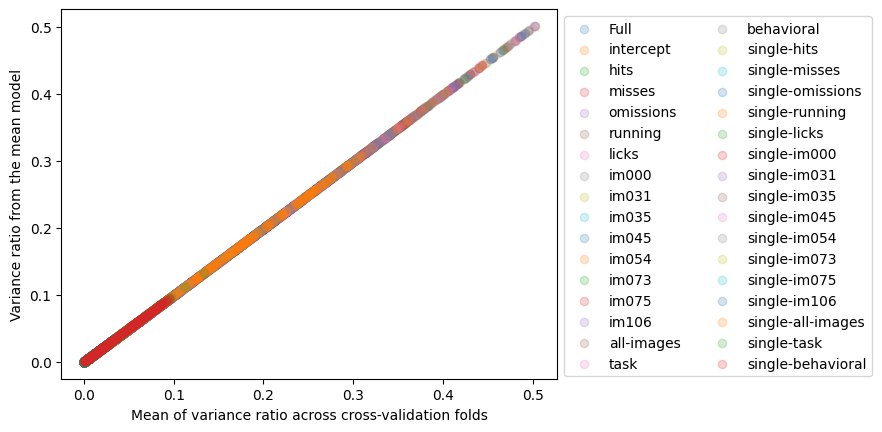

In [74]:
fig, ax = plt.subplots()
for model in var_ratio_mean_model.model.values:
    ax.scatter(mean_var_ratio.sel(model=model), var_ratio_mean_model.sel(model=model), label=model, alpha=0.2)
ax.set_xlabel('Mean of variance ratio across cross-validation folds')
ax.set_ylabel('Variance ratio from the mean model')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=2)

In [75]:
(mean_var_ratio - var_ratio_mean_model).std()
# they are not the same, but they are close

<xarray.DataArray ()> Size: 8B
array(0.0003429)

In [108]:
# gathering session model traces
# one from splits, another from the mean model
models = W_cv.model.values
session_model_from_splits = xr.DataArray(np.zeros((*response_trim.shape, len(models))),
                                         dims=['timestamps', 'cell_roi_id', 'model'],
                                         coords={'timestamps':response_trim.timestamps,
                                                 'cell_roi_id':response_trim.cell_roi_id,
                                                 'model':models})
for test_fold_ind in range(fit_params['cv_fold']):
    train_frames, test_frames, nested_fold_inds = get_train_test_inds(test_fold_ind, fit_params, stratified_frames, cv_inds_stratified)
    test_frames = np.sort(test_frames)

    X_test_outer = X_trim[test_frames, :]
    y_test_outer = response_trim[test_frames, :]
    
    W_fold = W_cv.sel(test_fold_ind=test_fold_ind)
    
    for mi, model in enumerate(models):
        W_fold_model = W_fold.sel(model=model)
        weights = W_fold_model.dropna(dim='weights').weights.values
        X_model = X_test_outer.sel(weights=weights)
        W_fold_model = W_fold_model.sel(weights=weights)
        
        # session_model_from_splits.sel(timestamps=test_timestamps, model=model)[:] = X_model.values @ W_fold_model.values
        # Somehow the above line does not work
        session_model_from_splits[test_frames, :, mi] = X_model.values @ W_fold_model.values
        
        
    

In [110]:
session_model_from_mean_W = xr.full_like(session_model_from_splits, fill_value=0, dtype=float)
for model in models:
    W_model = W_mean.sel(model=model)
    weights = W_model.dropna(dim='weights').weights.values
    X_model = X_trim.sel(weights=weights)
    W_model = W_model.sel(weights=weights)
    session_model_from_mean_W.sel(model=model)[:] = X_model.values @ W_model.values

(423.5729, 523.5729)

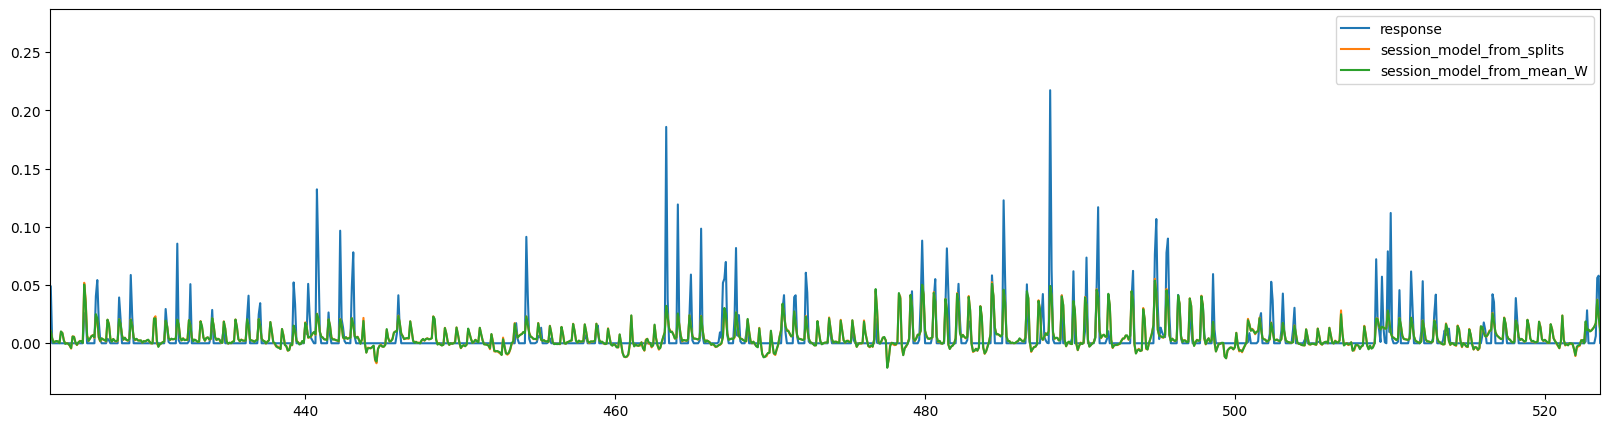

In [131]:
fig, ax = plt.subplots(figsize=(20,5))
ci = -4
mi = 0
response = response_trim.isel(cell_roi_id=ci)
session_model_split = session_model_from_splits.isel(cell_roi_id=ci, model=mi)
session_model_mean = session_model_from_mean_W.isel(cell_roi_id=ci, model=mi)

ax.plot(response.timestamps, response, label='response')
ax.plot(response.timestamps, session_model_split, label='session_model_from_splits')
ax.plot(response.timestamps, session_model_mean, label='session_model_from_mean_W')

ax.legend()

ax.set_xlim([response.timestamps[0]+100, response.timestamps[0]+200])

In [135]:
stratified_frames

[array([ 5098,  4246,  1564, ..., 37225, 37806, 34884]),
 array([  653,  1166,  4267, ..., 38025, 37434, 34885]),
 array([ 2791,  2299,   550, ..., 35782, 38236, 34891]),
 array([ 1493,  4540,   687, ..., 35314, 37841, 34897]),
 array([ 2736,  6761,  5993, ..., 35289, 34270, 34888]),
 array([ 6111,  4146,   564, ..., 36767, 36262, 34879]),
 array([ 3531,  3498,   195, ..., 36751, 38043, 34890]),
 array([ 7505,  4204,  1330, ..., 35279, 35681, 34882]),
 array([ 7283,  3535,  2007, ..., 37213, 37529, 36028]),
 array([ 1327,  2807,  1246, ..., 35188, 36085, 34889]),
 array([ 4074,   267,  2142, ..., 35712, 36837, 37862]),
 array([ 4453,  3194,  3774, ..., 36630, 36601, 34898]),
 array([  340,  6986,  3333, ..., 35615, 37871, 34892]),
 array([ 7431,  7194,  5465, ..., 35934, 38042, 34895]),
 array([ 6213,  4357,  3264, ..., 37269, 37037, 34880]),
 array([ 5366,    75,  6774, ..., 37782, 36905, 34887]),
 array([ 3069,  2401,  7113, ..., 35713, 38105, 34881]),
 array([ 2412,  3863,  3436, ..

In [136]:
# save the results
glm_results = {'fit_params': fit_params,
               'use_indices': use_indices,
               'stratified_frames': stratified_frames,
               'cv_inds_stratified': cv_inds_stratified,
               'lambdas_cv': lambdas_cv,
               'W_cv': W_cv,
               'var_ratio_train_cv': var_ratio_train_cv,
               'var_ratio_test_cv': var_ratio_test_cv,
               'vr_test_train_ratio_cv': vr_test_train_ratio_cv,
               'session_model_from_splits': session_model_from_splits,
               'session_model_from_mean_W': session_model_from_mean_W,
               'var_ratio_mean_model': var_ratio_mean_model}
save_dir = Path('/root/capsule/scratch')
save_fn = save_dir / f'glm_results_v{dm_version:02}_{session_name}_{data_type}.npy'
np.save(save_fn, glm_results)


In [141]:
print(save_fn)

/root/capsule/scratch/glm_results_v00_multiplane-ophys_721291_2024-05-16_08-57-00_filtered_events.npy


In [143]:
import os
os.path.getsize(save_fn) / 1e9

9.939585719

# Test loading

In [137]:
load_fn = save_dir / f'glm_results_v{dm_version:02}_{session_name}_{data_type}.npy'
glm_results_loaded = np.load(load_fn, allow_pickle=True).item()

In [139]:
glm_results_loaded.keys()

dict_keys(['fit_params', 'use_indices', 'stratified_frames', 'cv_inds_stratified', 'lambdas_cv', 'W_cv', 'var_ratio_train_cv', 'var_ratio_test_cv', 'vr_test_train_ratio_cv', 'session_model_from_splits', 'session_model_from_mean_W', 'var_ratio_mean_model'])

In [140]:
glm_results_loaded['W_cv']

<xarray.DataArray (test_fold_ind: 5, model: 34, weights: 168, cell_roi_id: 471)> Size: 108MB
array([[[[ 2.95612039e-03,  5.47972306e-04, -1.03380116e-03, ...,
           8.51665896e-04,  7.40196929e-03,  9.79474994e-03],
         [ 6.04333776e-03,  9.19028789e-05, -1.84447782e-03, ...,
          -2.08270475e-02,  2.67332832e-02,  3.59259547e-02],
         [-3.63411784e-03, -2.38590887e-04,  3.25249959e-04, ...,
           3.77013760e-04, -7.14328401e-04, -2.79549274e-03],
         ...,
         [-1.27066503e-03, -5.48272888e-04, -7.49516380e-04, ...,
          -4.70847277e-03, -3.72527644e-03, -5.30341392e-03],
         [-1.36275958e-04,  1.27789711e-04,  2.99538211e-05, ...,
           1.14359039e-03,  3.19100331e-04, -1.66917967e-03],
         [ 3.96108358e-04,  1.11761496e-03, -1.21128378e-03, ...,
           2.37815437e-03,  5.86791157e-04,  4.54974242e-03]],

        [[ 2.90830767e-03,  6.47589532e-04, -1.25890332e-03, ...,
           8.25528806e-04,  7.36612484e-03,  9.75078908e-03],
         [ 6.05863046e-03,  2.19399050e-04, -2.12346697e-03, ...,
          -2.08197201e-02,  2.67433320e-02,  3.59382789e-02],
         [-3.62482974e-03, -1.68460115e-04,  4.48140110e-04, ...,
           3.80853526e-04, -7.09062540e-04, -2.78903450e-03],
...
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [-4.91150520e-03, -1.19601092e-03, -1.20462233e-03, ...,
          -2.77410197e-02, -3.35063761e-02, -4.48317975e-02],
         [-9.94674435e-06,  9.85195374e-04,  1.40767960e-04, ...,
           2.06993616e-02,  2.45879524e-02,  2.92558126e-02],
         [ 1.79522972e-03,  9.43566738e-04,  1.34826232e-04, ...,
          -6.14965772e-03, -1.10371617e-02, -9.25446391e-03]]]])
Coordinates:
  * test_fold_ind  (test_fold_ind) int64 40B 0 1 2 3 4
  * weights        (weights) object 1kB 'hits_0' 'hits_1' ... 'running_9'
  * cell_roi_id    (cell_roi_id) object 4kB '1367059359_0001' ... '1367059367...
  * model          (model) object 272B 'Full' ... 'single-behavioral'

# Example plots for stratification threshold setting

In [127]:
licks = get_var_traces_from_X(X, use_indices, 'licks')
num_frames_one_min = np.round(ophys_frame_rate * 60).astype(int)
lick_freq = licks.rolling(timestamps=num_frames_one_min, center=True).sum().ffill(dim='timestamps').bfill(dim='timestamps')

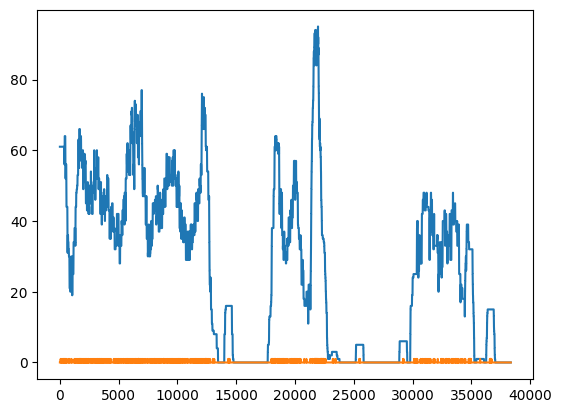

In [129]:
plt.plot(lick_freq)
plt.plot(licks)

In [134]:
correct = get_var_traces_from_X(X, use_indices, 'hits')
num_frames_one_min = np.round(ophys_frame_rate * 60).astype(int)
reward_freq = correct.rolling(timestamps=num_frames_one_min, center=True).sum().ffill(dim='timestamps').bfill(dim='timestamps')

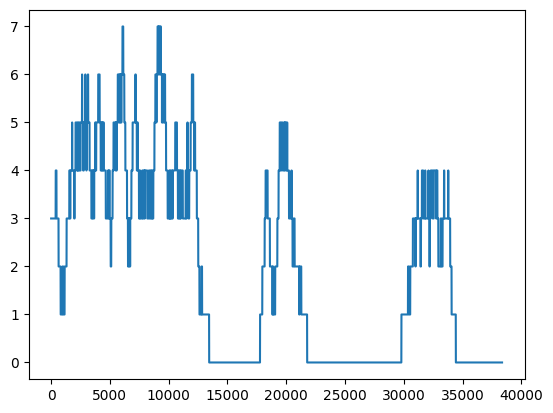

In [135]:
plt.plot(reward_freq)

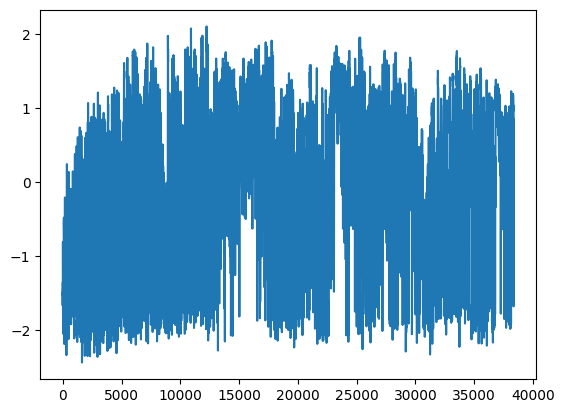

In [138]:
keyword = 'running'
running_speed = get_var_traces_from_X(X, use_indices, keyword)
plt.plot(running_speed)

# Archived functions

In [1]:
def fit_regularized_archived(y, X, lam):
    '''
    Analytical OLS solution with added L2 regularization penalty. 

    y: xr DataArray shape (n_timestamps * n_cells)
    X: xr DataArray shape (n_timestamps * n_kernel_params)
    lam (array): Strength of L2 regularization per cell (hyperparameter to tune)

    Returns: XArray
    '''
    if isinstance(lam, (int, float, np.generic)):
        lam = np.ones(y.shape[-1]) * lam
    elif isinstance(lam, np.ndarray):
        assert len(lam.shape) == 1
        if len(lam) == 1:
            lam = np.ones(y.shape[-1]) * lam
        else:
            assert len(lam) == y.shape[-1]
    else:
        raise TypeError(f'{type(lam)}')
    # Compute the weights

    # W = np.dot(np.linalg.inv(np.dot(X.T, X) + lam * np.eye(X.shape[-1])),
    #        np.dot(X.T, y))

    # W = np.linalg.solve(np.dot(X.T, X) + lam * np.eye(X.shape[-1]), np.dot(X.T, y))
    # W = np.linalg.solve(np.dot(X.T, X) + np.diag(lam), np.dot(X.T, y))
    
    reg_matrices = lam[:, None, None] * np.eye(X.shape[-1])
    X = X.expand_dims(cell_roi_id=y['cell_roi_id'].values)
    y = y.expand_dims(lam=lam)
    XT_X = np.matmul(X.values.transpose(0, 2, 1), X.values)
    XT_y = np.matmul(X.values.transpose(0, 2, 1), y.values.transpose(2,1,0)) # this takes 30 min
    
    A = XT_X + reg_matrices
    W = np.linalg.solve(A, XT_y).squeeze(-1)
    
    # Make xarray
    cellids = y['cell_roi_id'].values
    W_xarray= xr.DataArray(
            W, 
            dims =('weights','cell_roi_id'), 
            coords = {  'weights':X.weights.values, 
                        'cell_roi_id':cellids}
            )
    return W_xarray